In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!nvidia-smi
!pip install -q ultralytics

Sat Mar 14 17:39:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
from pathlib import Path

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
WORKING_DIR = Path("/kaggle/working")
DATASET_ROOT = Path("/kaggle/input/datasets/nguyenquynghia/image-dataset/dataset")


def _resolve_existing_path(candidates, glob_patterns, label):
    checked = [Path(path) for path in candidates]
    for candidate in checked:
        if candidate.exists():
            return candidate

    for pattern in glob_patterns:
        matches = sorted(KAGGLE_INPUT_ROOT.glob(pattern))
        if matches:
            return matches[0]

    checked_paths = "\n".join(f" - {path}" for path in checked)
    raise FileNotFoundError(f"Could not find {label}. Checked:\n{checked_paths}")


def resolve_src_dir():
    return _resolve_existing_path(
        candidates=[
            "/kaggle/input/datasets/phamtiensondeptrai1/src-training/src",
            "/kaggle/input/datasets/nguyenquynghia/src-training/src",
        ],
        glob_patterns=[
            "datasets/*/src-training/src",
        ],
        label="`src-training/src` dataset",
    )


def resolve_dataset_dir(name):
    dataset_dir = DATASET_ROOT / name
    if not dataset_dir.exists():
        raise FileNotFoundError(f"Missing dataset directory: {dataset_dir}")
    return dataset_dir


print("Kaggle dataset paths ready.")
print(f"Input root -> {KAGGLE_INPUT_ROOT}")
print(f"Dataset root -> {DATASET_ROOT}")

Kaggle dataset paths ready.
Input root -> /kaggle/input
Dataset root -> /kaggle/input/datasets/nguyenquynghia/image-dataset/dataset


In [4]:
# Copy src only; read YOLO dataset directly from Kaggle input
import shutil
import sys

src_working = WORKING_DIR / "src"
if src_working.exists():
    shutil.rmtree(src_working)
shutil.copytree(resolve_src_dir(), src_working)
if str(src_working) not in sys.path:
    sys.path.insert(0, str(src_working))

from pathlib import Path
import yolo.config as yolo_config
import yolo.train as yolo_train_module

YOLO_DATASET_DIR = Path(resolve_dataset_dir("yolo"))
yolo_config.YOLO_DIR = YOLO_DATASET_DIR
yolo_train_module.YOLO_DIR = YOLO_DATASET_DIR

print(f"src -> {src_working}")
print(f"dataset/yolo read-only source -> {YOLO_DATASET_DIR}")
print(f"dataset.yaml -> {YOLO_DATASET_DIR / 'dataset.yaml'}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
src -> /kaggle/working/src
dataset/yolo read-only source -> /kaggle/input/datasets/nguyenquynghia/image-dataset/dataset/yolo
dataset.yaml -> /kaggle/input/datasets/nguyenquynghia/image-dataset/dataset/yolo/dataset.yaml


In [5]:
import yolo.train as train_yolo_module

print(f"Training YOLO from -> {train_yolo_module.YOLO_DIR}")
model = train_yolo_module.train(epochs=60, batch=32, img_size=640, workers=2)

Training YOLO from -> /kaggle/input/datasets/nguyenquynghia/image-dataset/dataset/yolo
YOLO device: 0,1 | workers: 2
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/nguyenquynghia/image-dataset/dataset/yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01

In [6]:
import yolo.train as validate_yolo_module

print(f"Validating YOLO from -> {validate_yolo_module.YOLO_DIR}")
validate_yolo_module.validate()

Validating YOLO from -> /kaggle/input/datasets/nguyenquynghia/image-dataset/dataset/yolo
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 980.4±639.3 MB/s, size: 7011.2 KB)
val: Scanning /kaggle/input/datasets/nguyenquynghia/image-dataset/dataset/yolo/labels/val... 519 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 519/519 766.2it/s 0.7s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/nguyenquynghia/image-dataset/dataset/yolo/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 1.1s/it 34.7s
                   all        519        519      0.947      0.956      0.983      0.766
Speed: 0.7ms preprocess, 3.4ms inference, 0.0ms loss, 1

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a27b2d5c590>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Sample: ISIC_0000032.jpg
Validation source -> /kaggle/input/datasets/nguyenquynghia/image-dataset/dataset/yolo/images/val


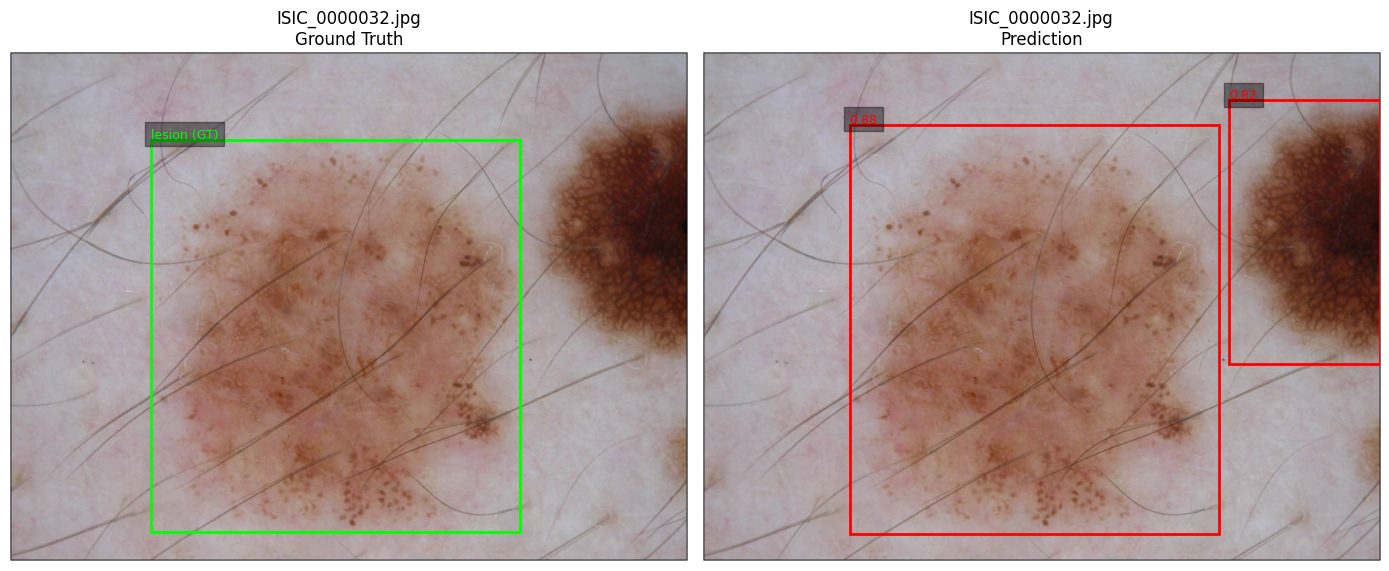

GT: 1  Predicted: 2


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
from ultralytics import YOLO

import yolo.config as yolo_config

weights_path = str(yolo_config.YOLO_OUTPUT / "lesion_detect" / "weights" / "best.pt")
model = YOLO(weights_path)

val_dir = yolo_config.YOLO_DIR / "images" / "val"
sample_img = sorted(val_dir.glob("*.jpg"))[0]
print(f"Sample: {sample_img.name}")
print(f"Validation source -> {val_dir}")

img = np.array(Image.open(sample_img).convert("RGB"))
height, width = img.shape[:2]

label_path = yolo_config.YOLO_DIR / "labels" / "val" / sample_img.with_suffix(".txt").name
gt_boxes = []
if label_path.exists():
    for line in label_path.read_text().strip().splitlines():
        _, cx, cy, bw, bh = map(float, line.split())
        gt_boxes.append(((cx - bw / 2) * width, (cy - bh / 2) * height, (cx + bw / 2) * width, (cy + bh / 2) * height))

results = model.predict(source=str(sample_img), imgsz=640, conf=0.25, verbose=False)
pred_boxes = results[0].boxes.xyxy.cpu().numpy()
pred_confs = results[0].boxes.conf.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, title in zip(axes, ["Ground Truth", "Prediction"]):
    ax.imshow(img)
    ax.set_title(f"{sample_img.name}\n{title}")
    ax.axis("off")

for (x1, y1, x2, y2) in gt_boxes:
    axes[0].add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, lw=2, edgecolor="lime", facecolor="none"))
    axes[0].text(x1, y1 - 4, "lesion (GT)", color="lime", fontsize=9, bbox=dict(facecolor="black", alpha=0.4))

for (x1, y1, x2, y2), conf in zip(pred_boxes, pred_confs):
    axes[1].add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, lw=2, edgecolor="red", facecolor="none"))
    axes[1].text(x1, y1 - 4, f"{conf:.2f}", color="red", fontsize=9, bbox=dict(facecolor="black", alpha=0.4))

plt.tight_layout()
plt.show()
print(f"GT: {len(gt_boxes)}  Predicted: {len(pred_boxes)}")

In [8]:
import zipfile
from pathlib import Path

output_dir = Path("/kaggle/working/outputs/yolo")
output_zip = "/kaggle/working/yolo_weights.zip"

if output_dir.exists():
    with zipfile.ZipFile(output_zip, "w", zipfile.ZIP_DEFLATED) as zf:
        for f in output_dir.rglob("*"):
            if f.is_file():
                zf.write(f, f.relative_to("/kaggle/working"))
                print(f"  {f.relative_to('/kaggle/working')}")
    print(f"\nSaved → {output_zip}  (download from Kaggle Output tab)")
else:
    print("No YOLO output directory found.")

  outputs/yolo/lesion_detect/train_batch0.jpg
  outputs/yolo/lesion_detect/train_batch2.jpg
  outputs/yolo/lesion_detect/train_batch1.jpg
  outputs/yolo/lesion_detect/train_batch3252.jpg
  outputs/yolo/lesion_detect/BoxP_curve.png
  outputs/yolo/lesion_detect/train_batch3251.jpg
  outputs/yolo/lesion_detect/confusion_matrix.png
  outputs/yolo/lesion_detect/BoxF1_curve.png
  outputs/yolo/lesion_detect/BoxR_curve.png
  outputs/yolo/lesion_detect/val_batch2_labels.jpg
  outputs/yolo/lesion_detect/BoxPR_curve.png
  outputs/yolo/lesion_detect/val_batch1_labels.jpg
  outputs/yolo/lesion_detect/val_batch2_pred.jpg
  outputs/yolo/lesion_detect/train_batch3250.jpg
  outputs/yolo/lesion_detect/val_batch1_pred.jpg
  outputs/yolo/lesion_detect/confusion_matrix_normalized.png
  outputs/yolo/lesion_detect/val_batch0_pred.jpg
  outputs/yolo/lesion_detect/labels.jpg
  outputs/yolo/lesion_detect/results.csv
  outputs/yolo/lesion_detect/results.png
  outputs/yolo/lesion_detect/val_batch0_labels.jpg
  ou

In [9]:
import gc
import torch

for name in [
    "model", "model_yolo", "results", "result", "pred_boxes", "pred_confs",
    "img", "sample_img", "gt_boxes"
]:
    globals().pop(name, None)

collected = gc.collect()
torch.cuda.empty_cache()

print(f"Python objects collected: {collected}")

Python objects collected: 32287


# Training medsam

In [10]:
!pip install -q segment-anything scikit-learn tqdm

In [11]:
# Download SAM ViT-B checkpoint
import os, subprocess

ckpt_path = "/kaggle/working/medsam_vit_b.pth"
if not os.path.exists(ckpt_path):
    subprocess.run(
        ["wget", "-q",
         "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth",
         "-O", ckpt_path],
        check=True,
    )
    print(f"Downloaded → {ckpt_path}")
else:
    print(f"Checkpoint already exists: {ckpt_path}")

Downloaded → /kaggle/working/medsam_vit_b.pth


In [12]:
import shutil
import sys
from pathlib import Path

src_working = WORKING_DIR / "src"
shutil.rmtree(src_working, ignore_errors=True)
shutil.copytree(resolve_src_dir(), src_working)
if str(src_working) not in sys.path:
    sys.path.insert(0, str(src_working))

import medsam.config as medsam_config
import medsam.train_segmentation as train_medsam_module

MEDSAM_DATASET_DIR = Path(resolve_dataset_dir("medsam"))
medsam_config.MEDSAM_DIR = MEDSAM_DATASET_DIR
train_medsam_module.MEDSAM_DIR = MEDSAM_DATASET_DIR

train_n = len(list((MEDSAM_DATASET_DIR / "train").glob("*.npz")))
val_n = len(list((MEDSAM_DATASET_DIR / "val").glob("*.npz")))
print(f"src -> {src_working}")
print(f"dataset/medsam read-only source -> {MEDSAM_DATASET_DIR}")
print(f"MedSAM files: train={train_n}, val={val_n}")
assert train_n > 0 and val_n > 0, "Empty MedSAM split. Check Kaggle input dataset layout."

src -> /kaggle/working/src
dataset/medsam read-only source -> /kaggle/input/datasets/nguyenquynghia/image-dataset/dataset/medsam
MedSAM files: train=2075, val=519


In [13]:
!nvidia-smi

Sat Mar 14 19:38:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P0             30W /   70W |     127MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
import medsam.train_segmentation as train_medsam_module

print(f"Training MedSAM from -> {train_medsam_module.MEDSAM_DIR}")
train_medsam_module.train(epochs=7, batch=2, lr=1e-4, workers=2)

Training MedSAM from -> /kaggle/input/datasets/nguyenquynghia/image-dataset/dataset/medsam
Device: cuda
Loading MedSAM from /kaggle/working/medsam_vit_b.pth
Using DataParallel on 2 GPUs
DataLoader workers: 2
Train: 2075  Val: 519


MedSAM epochs:   0%|          | 0/7 [00:00<?, ?it/s]

  train:   0%|          | 0/1038 [00:00<?, ?it/s]

  val:   0%|          | 0/260 [00:00<?, ?it/s]

Epoch   1/7 | train_loss: 0.2426 | val_loss: 0.2311 | val_dice: 0.9349 | val_iou: 0.8811 | lr: 9.50e-05 | 1714.7s
  → saved best model (dice=0.9349)


...

  val:   0%|          | 0/260 [00:00<?, ?it/s]

Epoch   6/7 | train_loss: 0.1705 | val_loss: 0.1890 | val_dice: 0.9485 | val_iou: 0.9050 | lr: 4.95e-06 | 1719.2s
  → saved best model (dice=0.9485)


  train:   0%|          | 0/1038 [00:00<?, ?it/s]

  val:   0%|          | 0/260 [00:00<?, ?it/s]

Epoch   7/7 | train_loss: 0.1608 | val_loss: 0.1847 | val_dice: 0.9490 | val_iou: 0.9061 | lr: 0.00e+00 | 1719.3s
  → saved best model (dice=0.9490)
Training complete. Best val dice: 0.9490


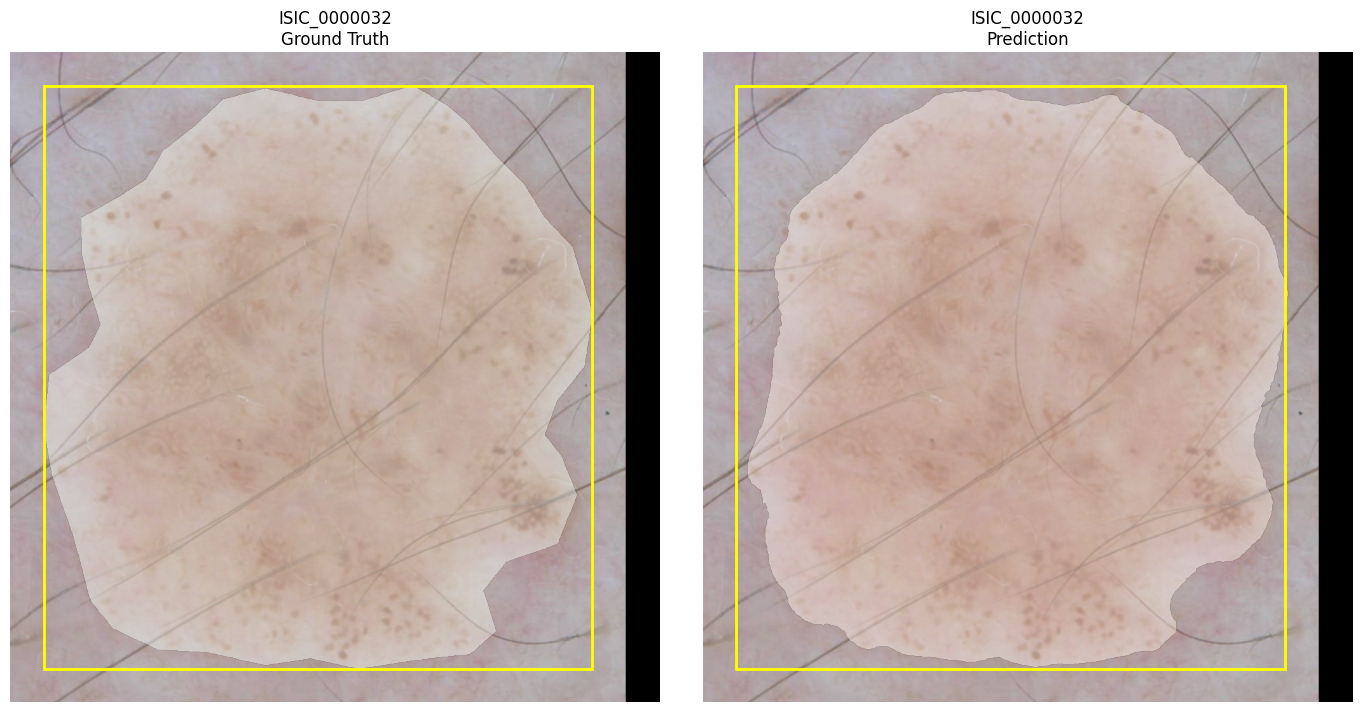

Validation source -> /kaggle/input/datasets/nguyenquynghia/image-dataset/dataset/medsam/val
Sample: ISIC_0000032
Dice: 0.9780  IoU: 0.9569  GT pixels: 621622  Pred pixels: 616863


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
import torch.nn.functional as F

import medsam.config as medsam_config
from medsam.models import MedSAM

MEDSAM_DIR = medsam_config.MEDSAM_DIR
MEDSAM_OUTPUT = medsam_config.MEDSAM_OUTPUT
MEDSAM_CHECKPOINT = medsam_config.MEDSAM_CHECKPOINT
DEVICE = medsam_config.DEVICE

weights_path = MEDSAM_OUTPUT / "medsam_best.pth"
assert weights_path.exists(), f"Missing trained weights: {weights_path}"

val_files = sorted((MEDSAM_DIR / "val").glob("*.npz"))
assert len(val_files) > 0, f"No validation npz files found in {MEDSAM_DIR / 'val'}"

sample_npz = val_files[0]
data = np.load(sample_npz)
image = data["image"].astype(np.uint8)
gt_mask = data["mask"].astype(np.uint8)
bbox = data["bbox"].astype(np.float32)

model = MedSAM(checkpoint=MEDSAM_CHECKPOINT).to(DEVICE)
state = torch.load(weights_path, map_location=DEVICE)
model.load_state_dict(state)
model.eval()

image_t = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE) / 255.0
bbox_t = torch.from_numpy(bbox).unsqueeze(0).float().to(DEVICE)

with torch.no_grad():
    pred_logits = model(image_t, bbox_t)
    pred_logits = F.interpolate(pred_logits, size=gt_mask.shape, mode="bilinear", align_corners=False)
    pred_prob = torch.sigmoid(pred_logits)[0, 0].cpu().numpy()

pred_mask = (pred_prob > 0.5).astype(np.uint8)

gt_bool = gt_mask.astype(bool)
pred_bool = pred_mask.astype(bool)
intersection = np.logical_and(gt_bool, pred_bool).sum()
union = np.logical_or(gt_bool, pred_bool).sum()
dice = (2 * intersection + 1e-8) / (gt_bool.sum() + pred_bool.sum() + 1e-8)
iou = (intersection + 1e-8) / (union + 1e-8)

x1, y1, x2, y2 = bbox

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, title in zip(axes, ["Ground Truth", "Prediction"]):
    ax.imshow(image)
    ax.set_title(f"{sample_npz.stem}\n{title}")
    ax.axis("off")
    ax.add_patch(
        patches.Rectangle((x1, y1), x2 - x1, y2 - y1, lw=2, edgecolor="yellow", facecolor="none")
    )

axes[0].imshow(np.ma.masked_where(gt_mask == 0, gt_mask), cmap="Greens", alpha=0.45)
axes[1].imshow(np.ma.masked_where(pred_mask == 0, pred_mask), cmap="Reds", alpha=0.45)

plt.tight_layout()
plt.show()

print(f"Validation source -> {MEDSAM_DIR / 'val'}")
print(f"Sample: {sample_npz.stem}")
print(f"Dice: {dice:.4f}  IoU: {iou:.4f}  GT pixels: {gt_bool.sum()}  Pred pixels: {pred_bool.sum()}")

In [16]:
import zipfile
from pathlib import Path

output_dir = Path("/kaggle/working/outputs/medsam")
output_zip = "/kaggle/working/medsam_lesion_weights.zip"

if output_dir.exists():
    with zipfile.ZipFile(output_zip, "w", zipfile.ZIP_DEFLATED) as zf:
        for f in output_dir.rglob("*"):
            if f.is_file():
                zf.write(f, f.relative_to("/kaggle/working"))
                print(f"  {f.relative_to('/kaggle/working')}")
    print(f"\nSaved → {output_zip}  (download from Kaggle Output tab)")
else:
    print("No MedSAM output directory found.")

  outputs/medsam/medsam_best.pth
  outputs/medsam/medsam_last.pth

Saved → /kaggle/working/medsam_lesion_weights.zip  (download from Kaggle Output tab)


In [17]:
import gc
import torch

for name in [
    "model", "train_medsam", "pred_logits", "pred_prob", "pred_mask",
    "image_t", "bbox_t", "gt_mask", "data", "sample_npz"
]:
    globals().pop(name, None)

collected = gc.collect()
torch.cuda.empty_cache()

print(f"Python objects collected: {collected}")

Python objects collected: 16382


# Training medsam attribute

In [18]:
# Copy src only; read attribute dataset directly from Kaggle input
import shutil
import sys
from pathlib import Path

src_working = WORKING_DIR / "src"
shutil.rmtree(src_working, ignore_errors=True)
shutil.copytree(resolve_src_dir(), src_working)
if str(src_working) not in sys.path:
    sys.path.insert(0, str(src_working))

import medsam.config as medsam_config
import medsam.train_attributes as train_attr_module

ATTRIBUTE_DATASET_DIR = Path(resolve_dataset_dir("attributes"))
medsam_config.ATTR_DIR = ATTRIBUTE_DATASET_DIR
train_attr_module.ATTR_DIR = ATTRIBUTE_DATASET_DIR

train_n = len(list((ATTRIBUTE_DATASET_DIR / "train").glob("*.npz")))
val_n = len(list((ATTRIBUTE_DATASET_DIR / "val").glob("*.npz")))
print(f"src -> {src_working}")
print(f"dataset/attributes read-only source -> {ATTRIBUTE_DATASET_DIR}")
print(f"Attribute files: train={train_n}, val={val_n}")
assert train_n > 0 and val_n > 0, "Empty attribute split. Check Kaggle input dataset layout."

src -> /kaggle/working/src
dataset/attributes read-only source -> /kaggle/input/datasets/nguyenquynghia/image-dataset/dataset/attributes
Attribute files: train=2075, val=519


In [19]:
from pathlib import Path

import medsam.config as medsam_config
import medsam.train_attributes as train_attr_module

attribute_dataset_dir = resolve_dataset_dir("attributes")
medsam_config.ATTR_DIR = Path(attribute_dataset_dir)
train_attr_module.ATTR_DIR = Path(attribute_dataset_dir)

print(f"Training attributes from -> {train_attr_module.ATTR_DIR}")
train_attr_module.train(epochs=20, batch=2, lr=1e-4, workers=2)

Training attributes from -> /kaggle/input/datasets/nguyenquynghia/image-dataset/dataset/attributes
Device: cuda
Initialising encoder from /kaggle/working/medsam_vit_b.pth
Using DataParallel on 2 GPUs
DataLoader workers: 2
Train: 2075  Val: 519


Attr epochs:   0%|          | 0/20 [00:00<?, ?it/s]

  train:   0%|          | 0/1038 [00:00<?, ?it/s]

  val:   0%|          | 0/260 [00:00<?, ?it/s]

Epoch   1/20 | train_loss: 0.9895 | val_loss: 0.9775 | mean_dice: 0.7320 | mean_iou: 0.7191 | lr: 9.94e-05 | 1173.2s
    globules                 : dice=0.7766  iou=0.7766
    milia_like_cyst          : dice=0.7537  iou=0.7537
    negative_network         : dice=0.9326  iou=0.9326
    pigment_network          : dice=0.2317  iou=0.1671
    streaks                  : dice=0.9653  iou=0.9653
  → saved best model (dice=0.7320)


...

  val:   0%|          | 0/260 [00:00<?, ?it/s]

Epoch  19/20 | train_loss: 0.9148 | val_loss: 0.9433 | mean_dice: 0.4785 | mean_iou: 0.4587 | lr: 6.16e-07 | 1118.0s


  train:   0%|          | 0/1038 [00:00<?, ?it/s]

  val:   0%|          | 0/260 [00:00<?, ?it/s]

Epoch  20/20 | train_loss: 0.9143 | val_loss: 0.9429 | mean_dice: 0.5038 | mean_iou: 0.4849 | lr: 0.00e+00 | 1116.9s
    globules                 : dice=0.1687  iou=0.1458
    milia_like_cyst          : dice=0.1670  iou=0.1612
    negative_network         : dice=0.9326  iou=0.9326
    pigment_network          : dice=0.3087  iou=0.2429
    streaks                  : dice=0.9420  iou=0.9420
Training complete. Best mean dice: 0.7320


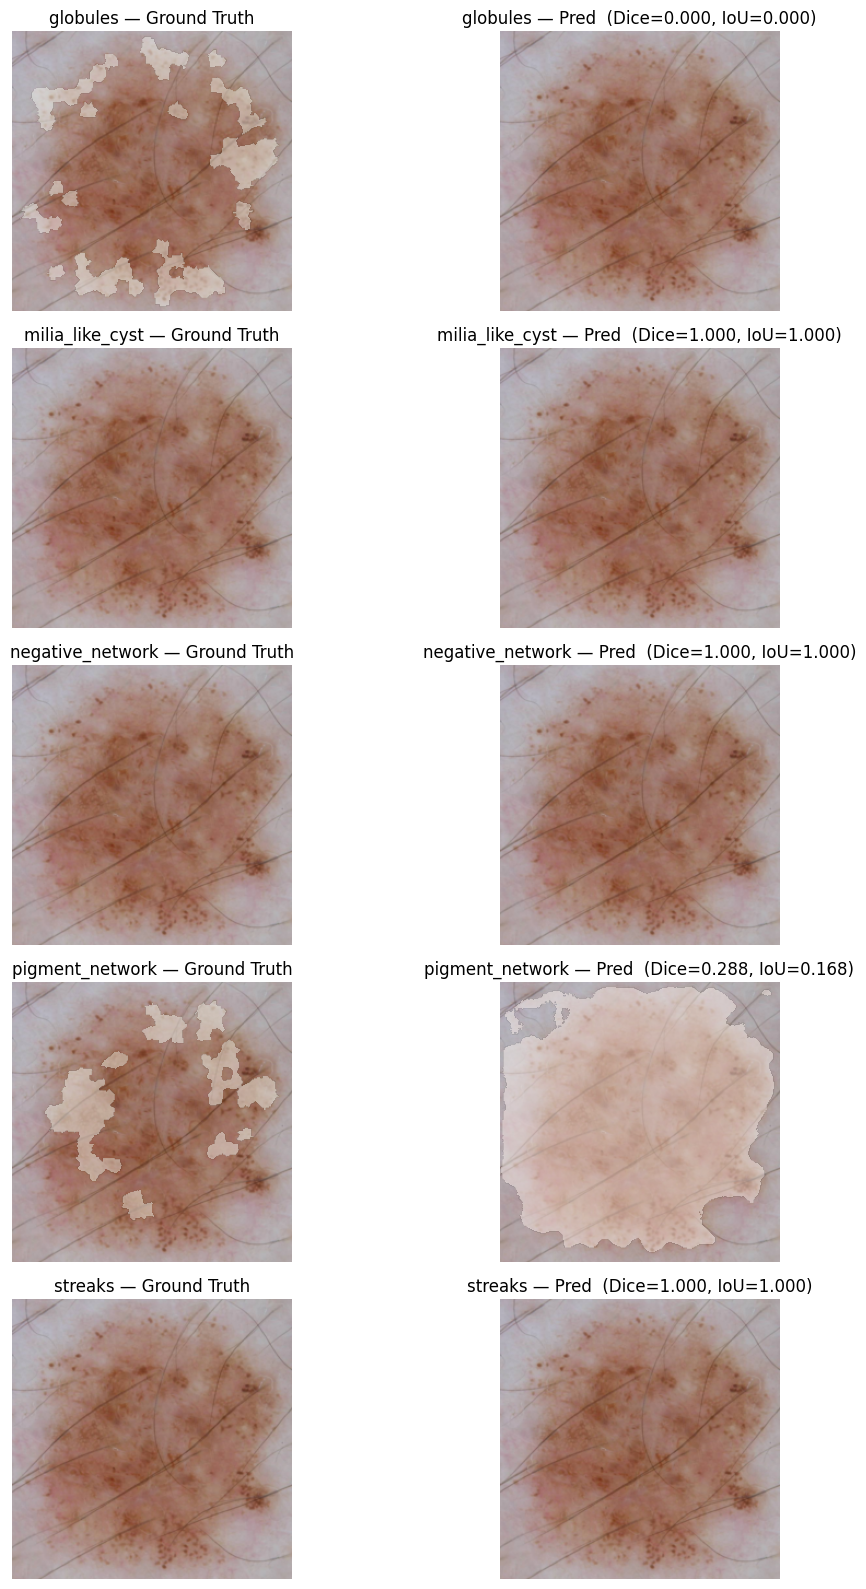

Mean Dice: 0.6576  Mean IoU: 0.6336


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from medsam.config import ATTR_DIR, ATTR_OUTPUT, ATTRIBUTES, MEDSAM_CHECKPOINT, MEDSAM_IMG_SIZE, DEVICE
from medsam.dataset import AttributeDataset
from medsam.models import AttributeSegModel

weights_path = ATTR_OUTPUT / "attr_best.pth"
assert weights_path.exists(), f"Missing trained weights: {weights_path}"

val_ds = AttributeDataset(ATTR_DIR / "val", augment=False)
assert len(val_ds) > 0, f"No validation samples found in {ATTR_DIR / 'val'}"

image_t, gt_masks_t = val_ds[0]  # image: (3,256,256), gt_masks: (5,256,256)
image_np = (image_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
gt_masks = gt_masks_t.numpy().astype(np.uint8)

model = AttributeSegModel(sam_checkpoint=MEDSAM_CHECKPOINT, freeze_encoder=True).to(DEVICE)
state = torch.load(weights_path, map_location=DEVICE)
model.load_state_dict(state)
model.eval()

with torch.no_grad():
    x = image_t.unsqueeze(0).to(DEVICE)
    x_1024 = F.interpolate(x, size=(MEDSAM_IMG_SIZE, MEDSAM_IMG_SIZE), mode="bilinear", align_corners=False)
    pred_logits = model(x_1024)
    pred_logits = F.interpolate(pred_logits, size=gt_masks.shape[-2:], mode="bilinear", align_corners=False)
    pred_prob = torch.sigmoid(pred_logits)[0].cpu().numpy()

pred_masks = (pred_prob > 0.5).astype(np.uint8)

num_attrs = len(ATTRIBUTES)
fig, axes = plt.subplots(num_attrs, 2, figsize=(12, 3.2 * num_attrs))
if num_attrs == 1:
    axes = np.expand_dims(axes, axis=0)

dice_list, iou_list = [], []
for i, attr in enumerate(ATTRIBUTES):
    gt = gt_masks[i].astype(bool)
    pred = pred_masks[i].astype(bool)

    inter = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()
    dice = (2 * inter + 1e-8) / (gt.sum() + pred.sum() + 1e-8)
    iou = (inter + 1e-8) / (union + 1e-8)
    dice_list.append(dice)
    iou_list.append(iou)

    axes[i, 0].imshow(image_np)
    axes[i, 0].imshow(np.ma.masked_where(~gt, gt), cmap="Greens", alpha=0.45)
    axes[i, 0].set_title(f"{attr} — Ground Truth")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(image_np)
    axes[i, 1].imshow(np.ma.masked_where(~pred, pred), cmap="Reds", alpha=0.45)
    axes[i, 1].set_title(f"{attr} — Pred  (Dice={dice:.3f}, IoU={iou:.3f})")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

print(f"Mean Dice: {np.mean(dice_list):.4f}  Mean IoU: {np.mean(iou_list):.4f}")

In [21]:
import zipfile
from pathlib import Path

output_dir = Path("/kaggle/working/outputs/attributes")
output_zip = "/kaggle/working/medsam_attributes_weights.zip"

if output_dir.exists():
    with zipfile.ZipFile(output_zip, "w", zipfile.ZIP_DEFLATED) as zf:
        for f in output_dir.rglob("*"):
            if f.is_file():
                zf.write(f, f.relative_to("/kaggle/working"))
                print(f"  {f.relative_to('/kaggle/working')}")
    print(f"\nSaved → {output_zip}  (download from Kaggle Output tab)")
else:
    print("No attribute output directory found.")

  outputs/attributes/attr_last.pth
  outputs/attributes/attr_best.pth
  outputs/attributes/attr_epoch20.pth
  outputs/attributes/attr_epoch10.pth

Saved → /kaggle/working/medsam_attributes_weights.zip  (download from Kaggle Output tab)


In [22]:
import gc
import torch

for name in [
    "model", "train_attr", "pred_logits", "pred_prob", "pred_masks",
    "image_t", "gt_masks_t", "x", "x_1024", "val_ds"
]:
    globals().pop(name, None)

collected = gc.collect()
torch.cuda.empty_cache()

print(f"Python objects collected: {collected}")

Python objects collected: 1103615
